In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point, test_summary
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
# compiling dfs
# folder = Path('./output/2025-12-10_14h50m47s_reconstr_grid_4')
# dev = pd.read_csv(folder/'dev.csv')
# test = pd.read_csv(folder/'test.csv')

folder = Path('./output/reconstr_grid4')
subfolders = ['t1', 't2', 't3', 't4']
dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

# get confs, update
confs_class = ConfigLookup(
    keys=['ema_norm','loss_weights'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    save=True,
)

confs = confs_class.data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

In [3]:
test['loss_weights'] = test['loss_weights'].astype(str)
test

,ema_norm,loss_weights,config,trial,metric,value
0,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,loss,0.492827
1,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,mse,0.733518
2,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,rmse,0.856457
3,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,mae,0.579835
4,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,r2,0.807927
...,...,...,...,...,...,...
2795,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,39,rmse,0.852724
2796,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,39,mae,0.579605
2797,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,39,r2,0.807758
2798,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,39,kld,257.596283


In [4]:
test_summary(test, save_csv=True, filename=folder/'summary.csv')

,config,metric,mean,sd,ci
0,losskwargsEmanormFalselossclassesMSELossKLDLos...,kld,0.309298,1.029130,0.329132
1,losskwargsEmanormFalselossclassesMSELossKLDLos...,loss,0.511872,0.025936,0.008295
2,losskwargsEmanormFalselossclassesMSELossKLDLos...,mae,0.586220,0.012275,0.003926
3,losskwargsEmanormFalselossclassesMSELossKLDLos...,mse,0.743986,0.030341,0.009704
4,losskwargsEmanormFalselossclassesMSELossKLDLos...,r2,0.806328,0.007103,0.002272
...,...,...,...,...,...
65,losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.574813,0.021789,0.006968
66,losskwargsEmanormTruelossclassesMSELossKLDLoss...,mse,0.719310,0.048518,0.015517
67,losskwargsEmanormTruelossclassesMSELossKLDLoss...,r2,0.812785,0.011664,0.003730
68,losskwargsEmanormTruelossclassesMSELossKLDLoss...,rmse,0.847641,0.028913,0.009247


In [5]:
test['trial'].max()

39

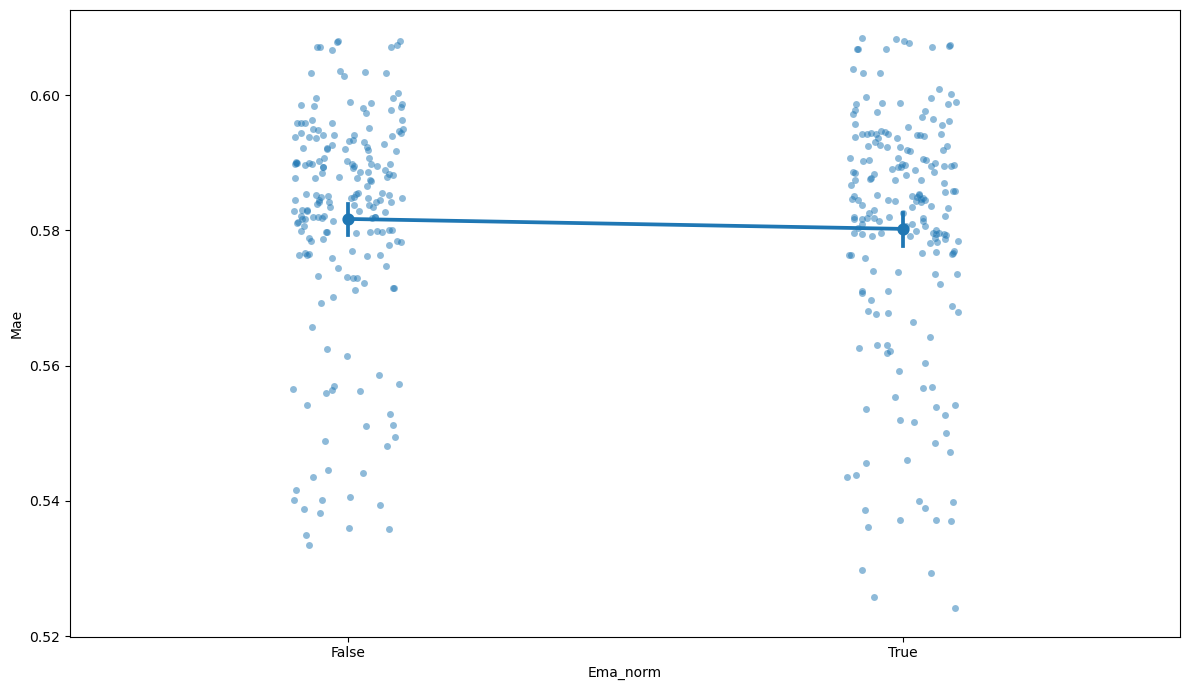

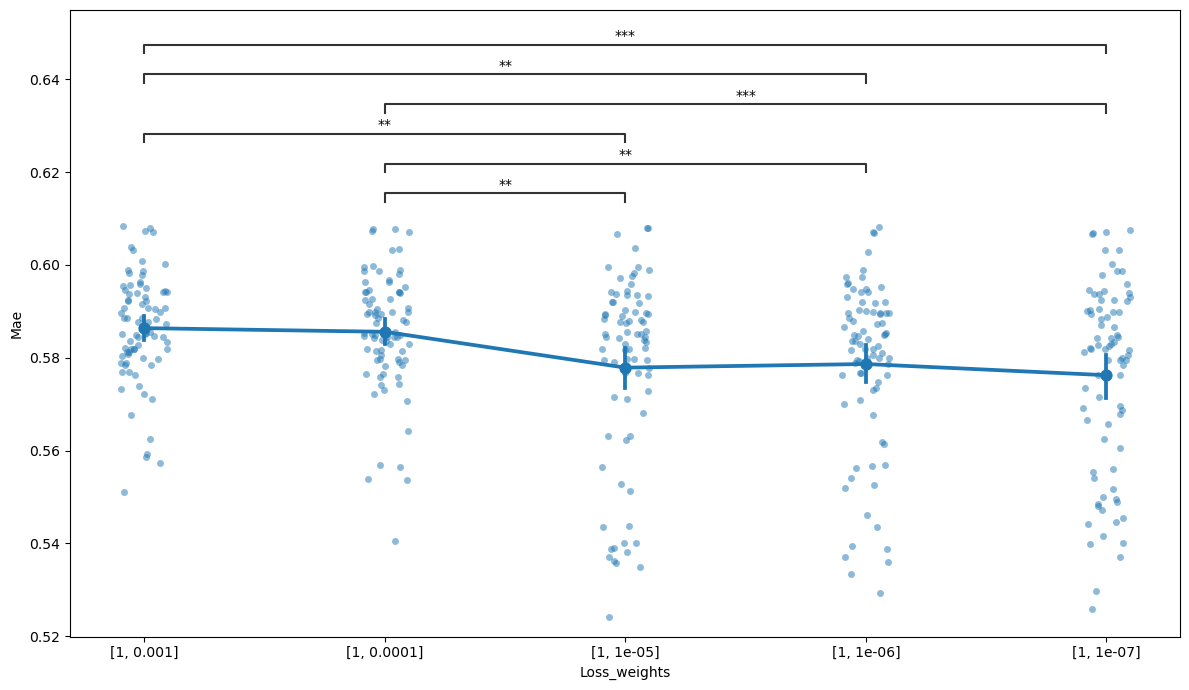

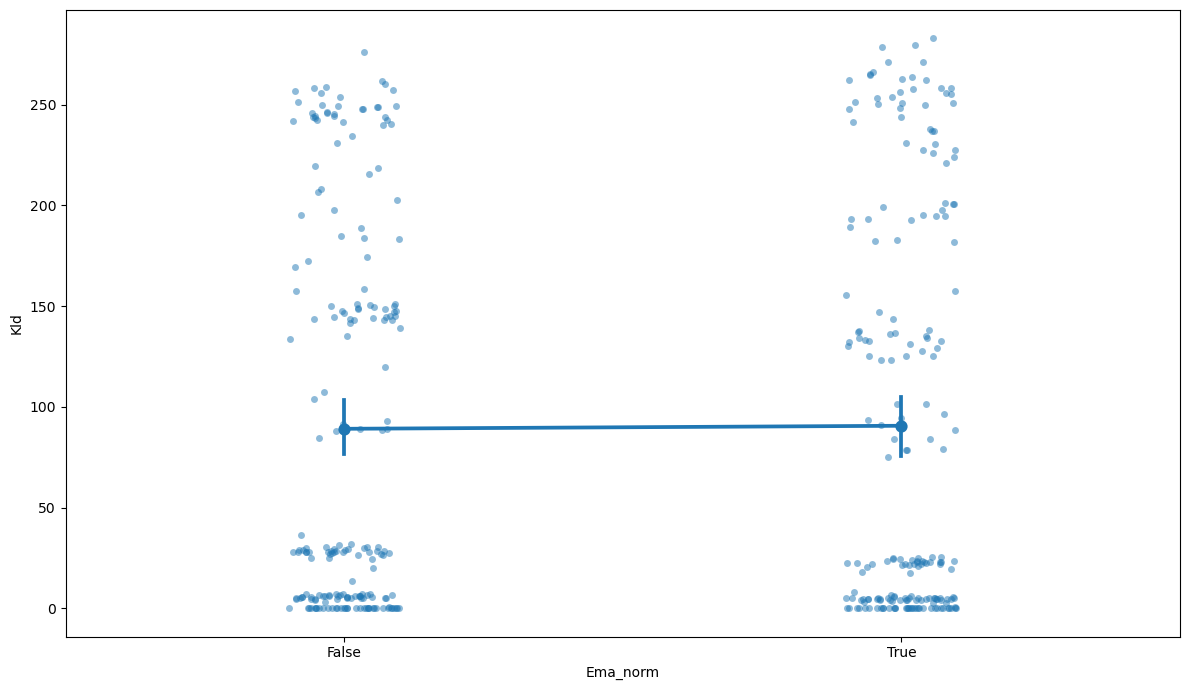

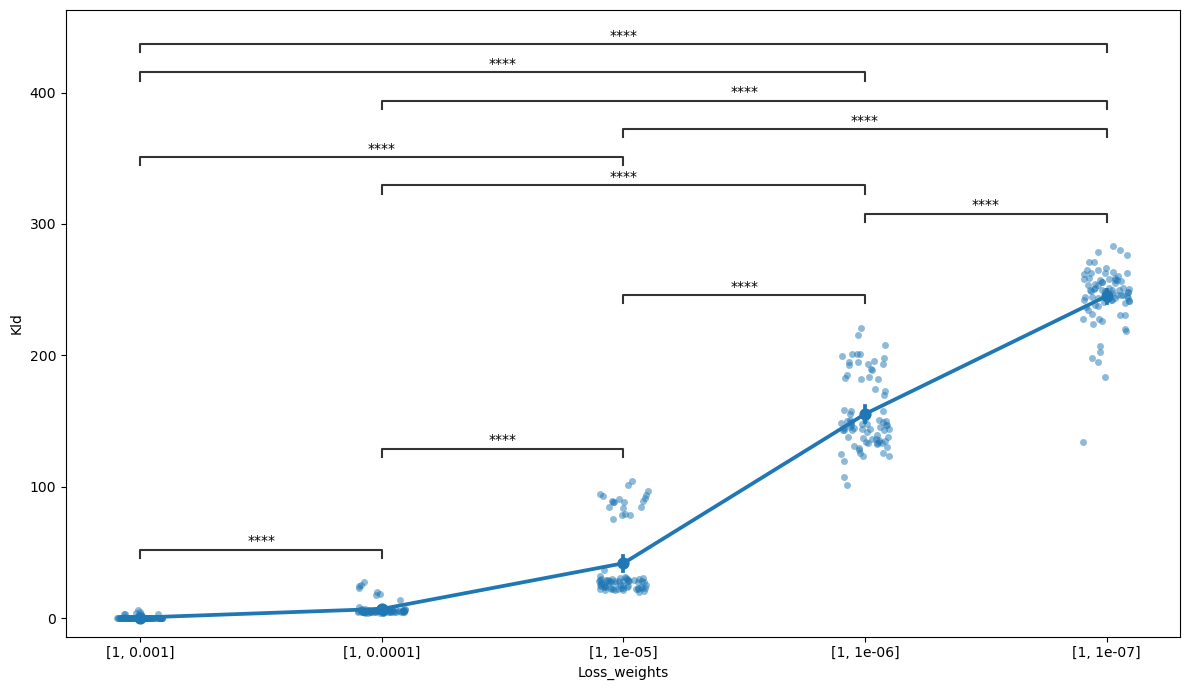

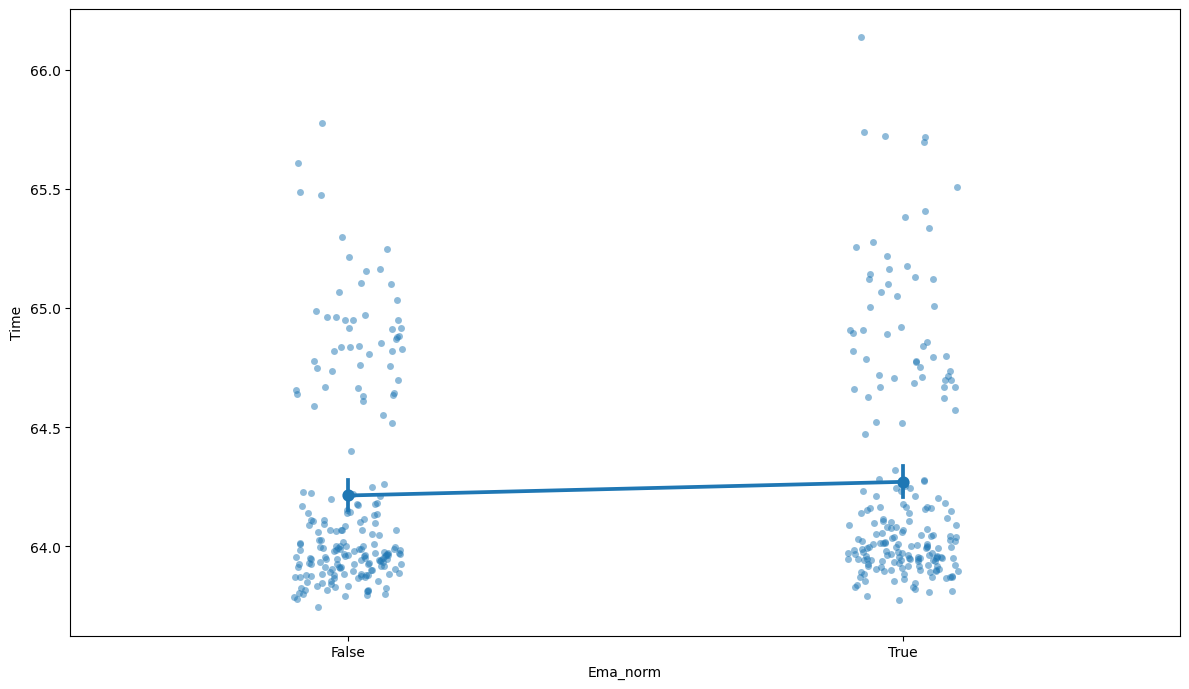

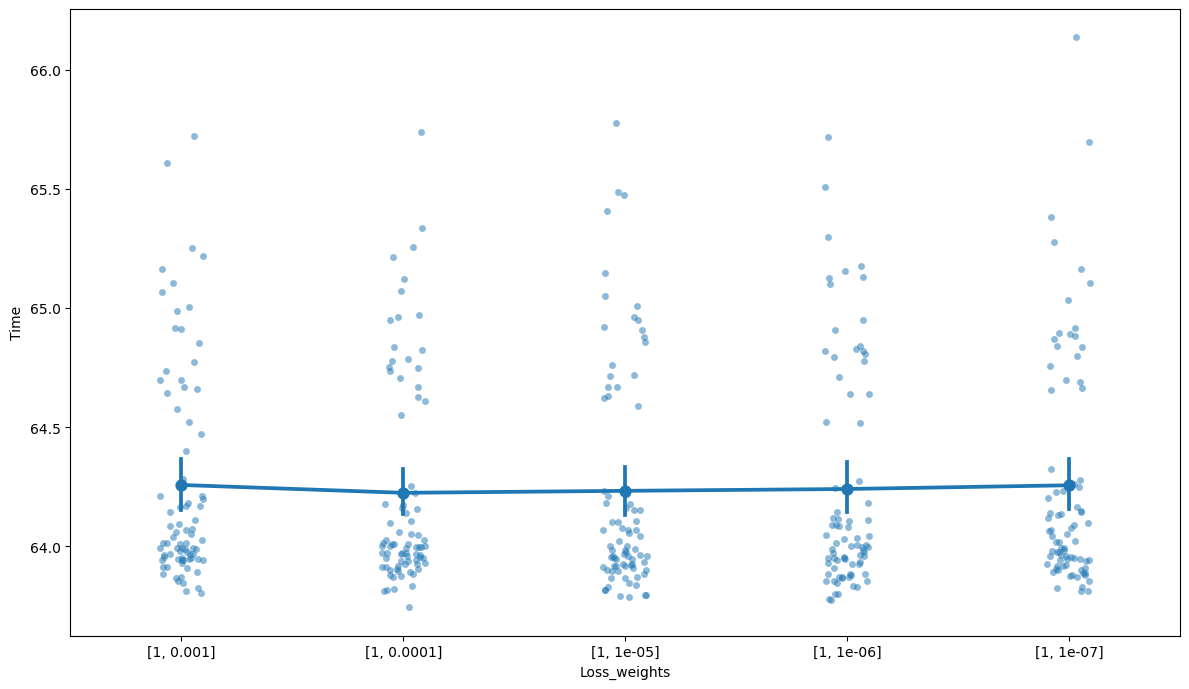

In [6]:
metric_x_point(
    df=test, 
    cols=['ema_norm','loss_weights'],
    metrics=['mae', 'kld', 'time'],
    figsize=(12,7),
    strip=True,
    sig=True
)

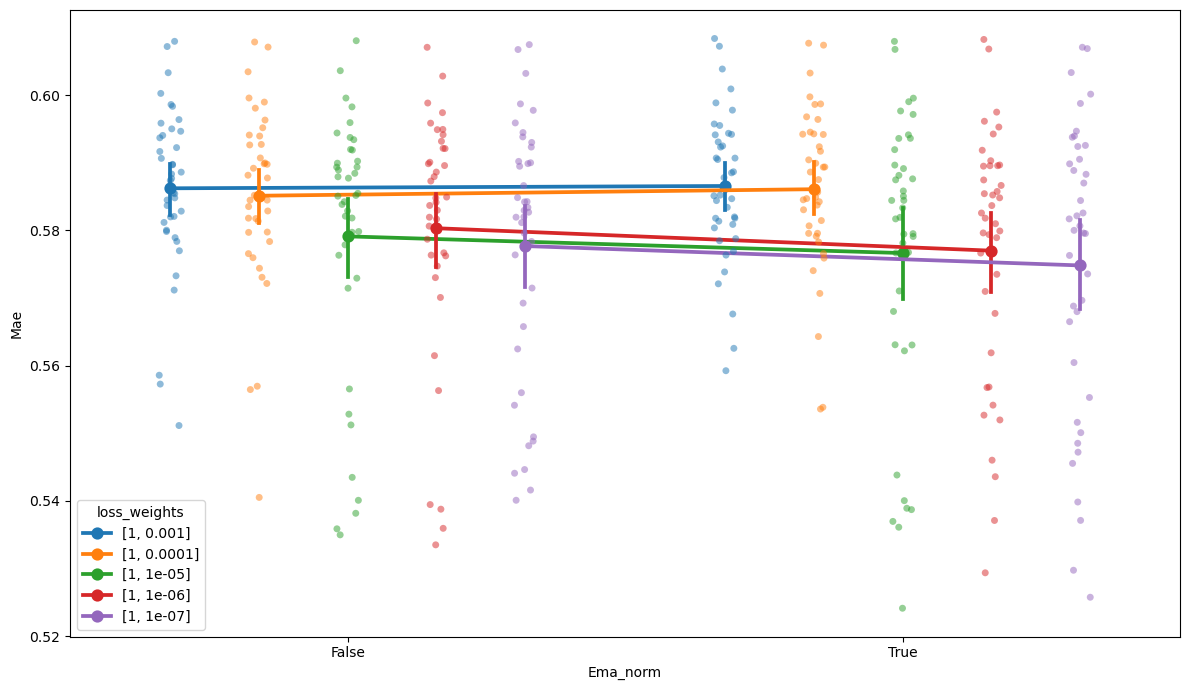

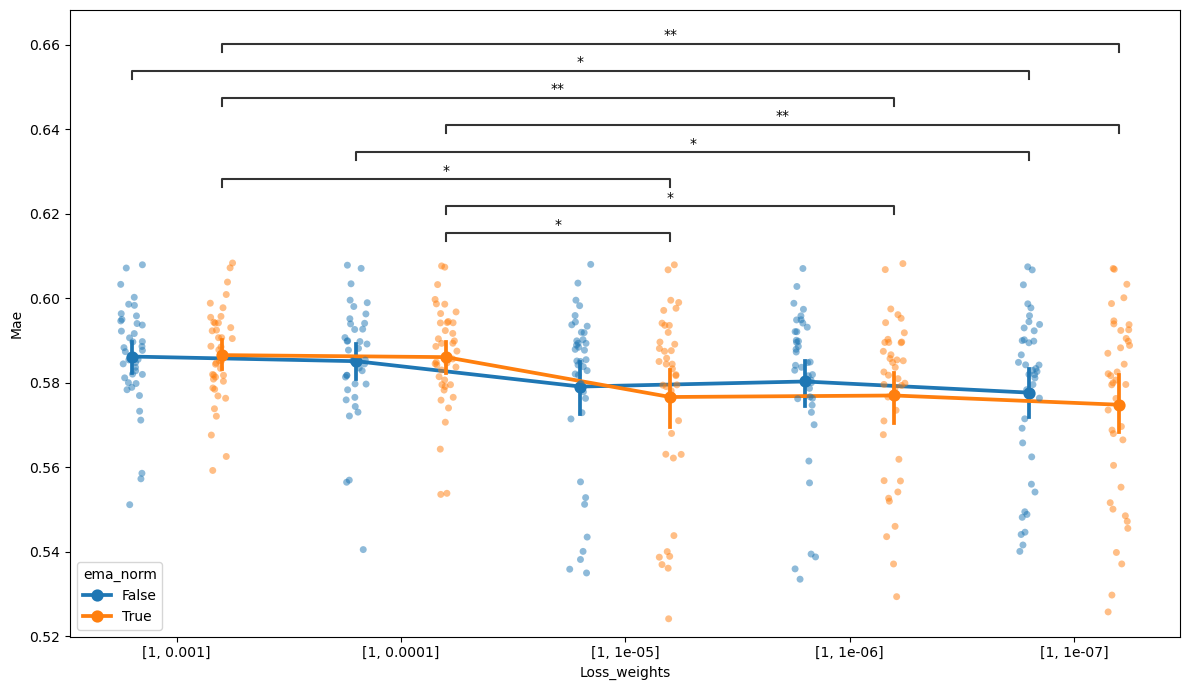

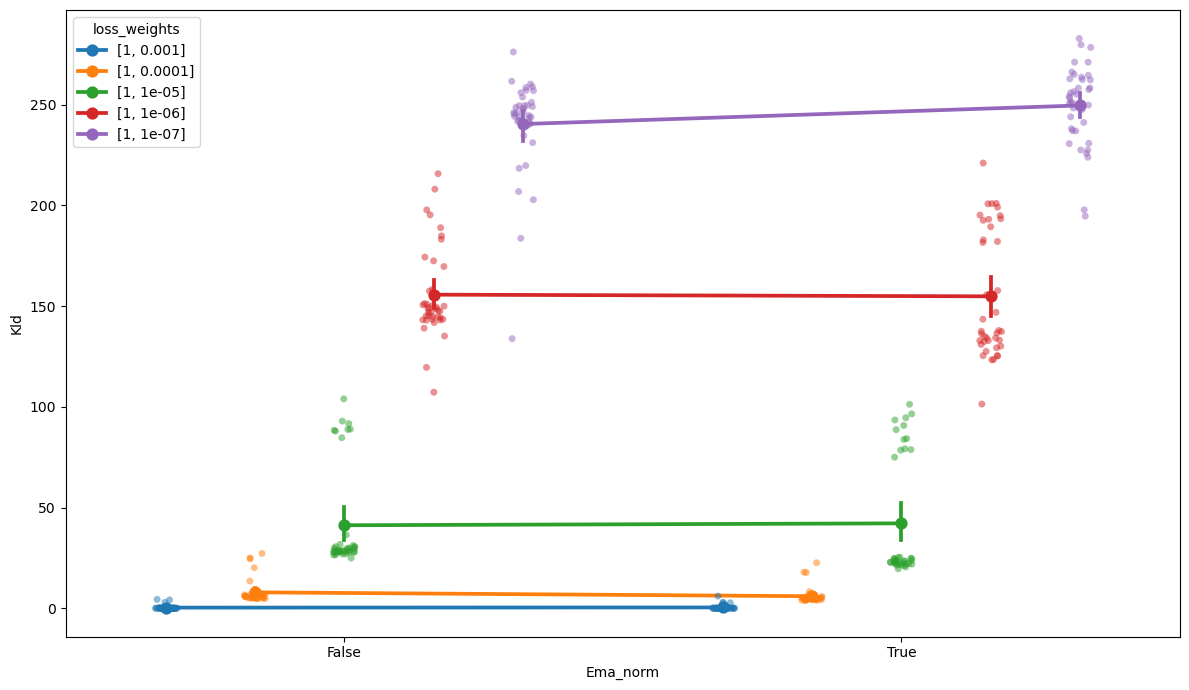

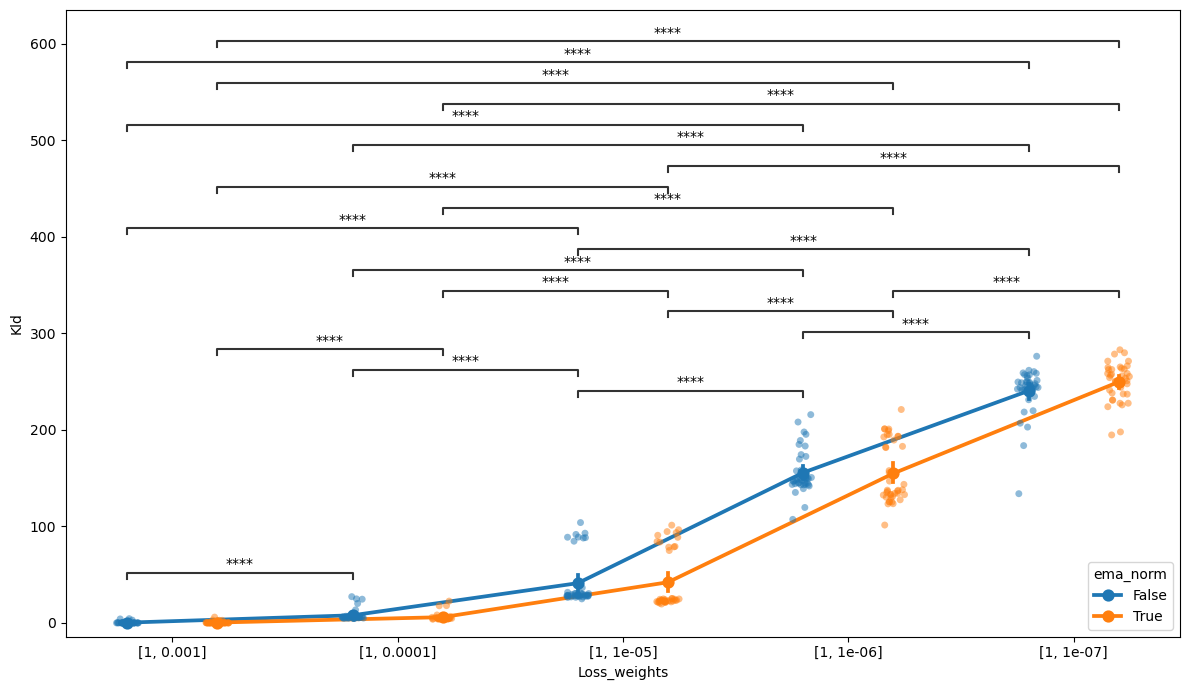

In [7]:
metric_x_point(
    df=test, 
    cols=['ema_norm','loss_weights'],
    metrics=['mae', 'kld'],
    figsize=(12,7),
    strip=True,
    sig='between',
    hue=True
)

In [8]:
from modules.viz import devplot

In [9]:
dev['loss_weights'] = dev['loss_weights'].astype(str)
dev

,ema_norm,loss_weights,config,trial,epoch,stage,metric,value
0,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,0,train,loss,1.105469
1,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,0,train,mse,0.822762
2,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,0,train,rmse,0.907062
3,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,0,train,mae,0.619385
4,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,0,0,train,r2,0.784915
...,...,...,...,...,...,...,...,...
239995,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,39,49,val,mse,0.721413
239996,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,39,49,val,rmse,0.849360
239997,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,39,49,val,mae,0.575786
239998,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,39,49,val,r2,0.810070


In [10]:
summary = pd.read_csv(folder/'summary.csv')
summary = pd.merge(confs,summary,on='config')
summary['loss_weights'] = summary['loss_weights'].astype(str)
summary


,ema_norm,loss_weights,config,metric,mean,sd,ci
0,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,kld,0.309298,1.029130,0.329132
1,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,loss,0.511872,0.025936,0.008295
2,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,mae,0.586220,0.012275,0.003926
3,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,mse,0.743986,0.030341,0.009704
4,False,"[1, 0.001]",losskwargsEmanormFalselossclassesMSELossKLDLos...,r2,0.806328,0.007103,0.002272
...,...,...,...,...,...,...,...
65,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.574813,0.021789,0.006968
66,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,mse,0.719310,0.048518,0.015517
67,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,r2,0.812785,0.011664,0.003730
68,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,rmse,0.847641,0.028913,0.009247


In [11]:
figs = devplot(
    dev=dev,
    summary=summary,
    metrics=['mae', 'kld']
)

In [12]:
for key in figs.keys():
    print(key)

losskwargsEmanormFalselossclassesMSELossKLDLosslossweights11e-3
losskwargsEmanormFalselossclassesMSELossKLDLosslossweights11e-4
losskwargsEmanormFalselossclassesMSELossKLDLosslossweights11e-5
losskwargsEmanormFalselossclassesMSELossKLDLosslossweights11e-6
losskwargsEmanormFalselossclassesMSELossKLDLosslossweights11e-7
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-3
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-4
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-5
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-6
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-7


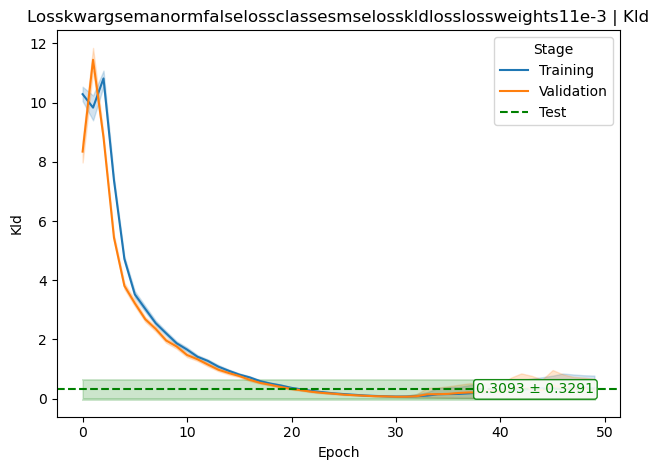

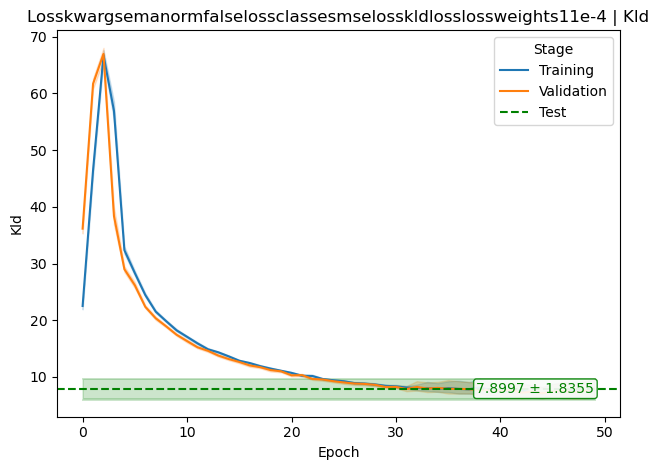

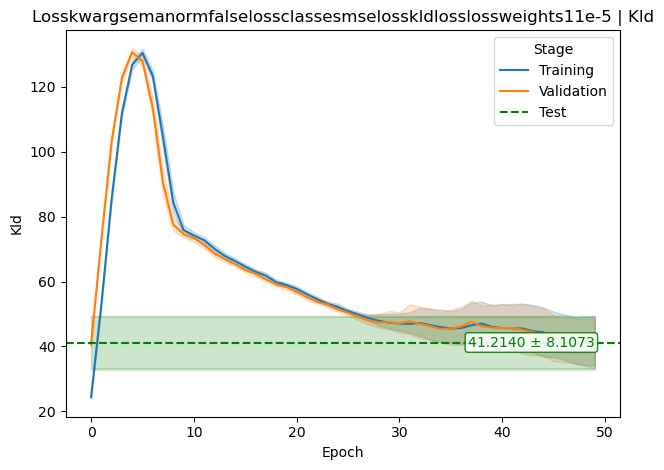

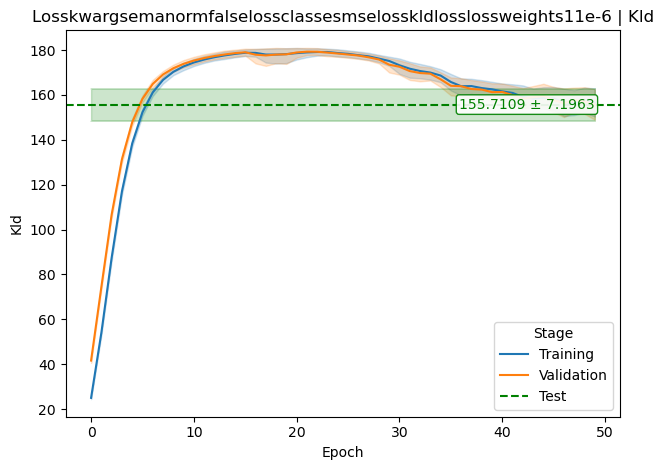

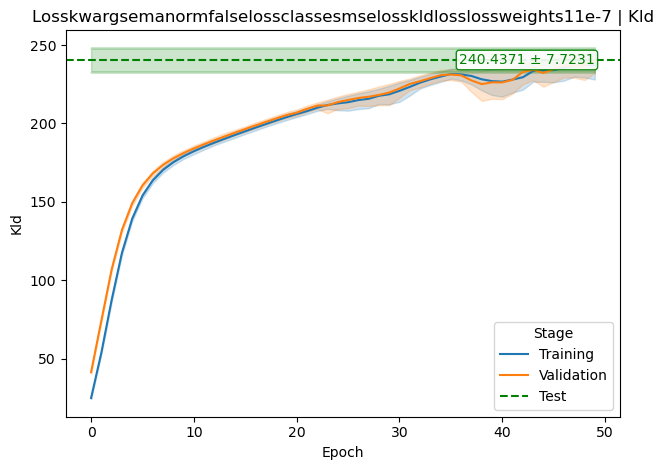

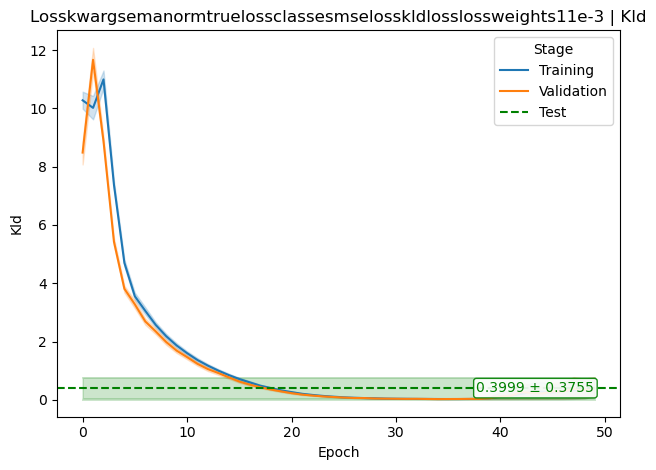

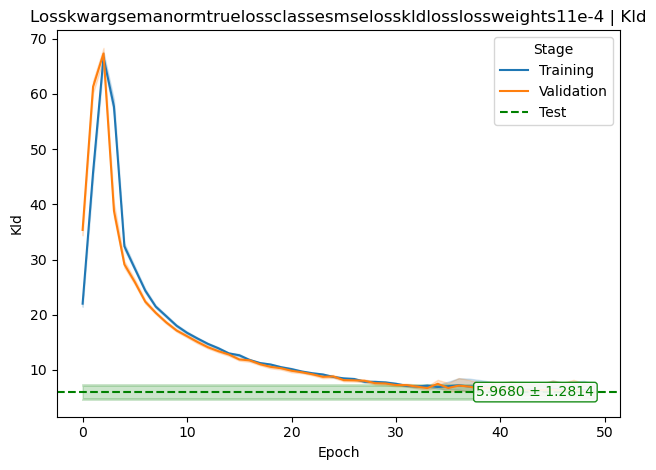

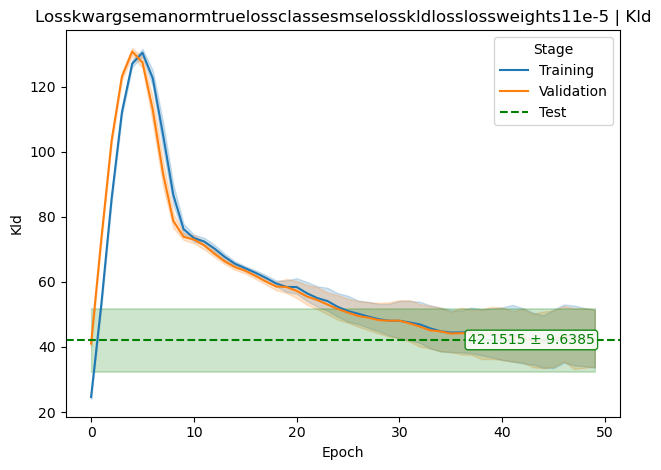

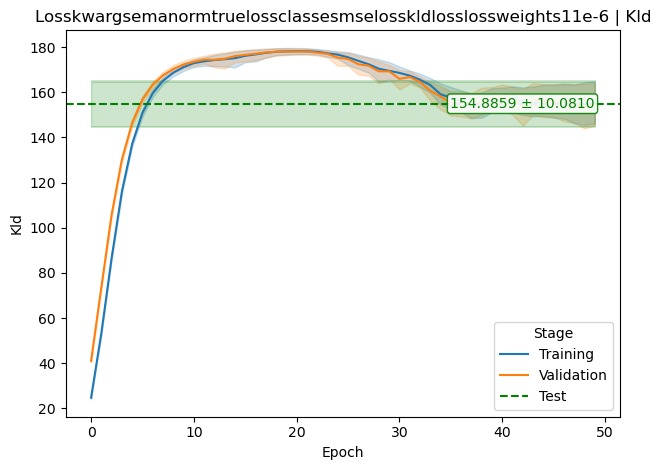

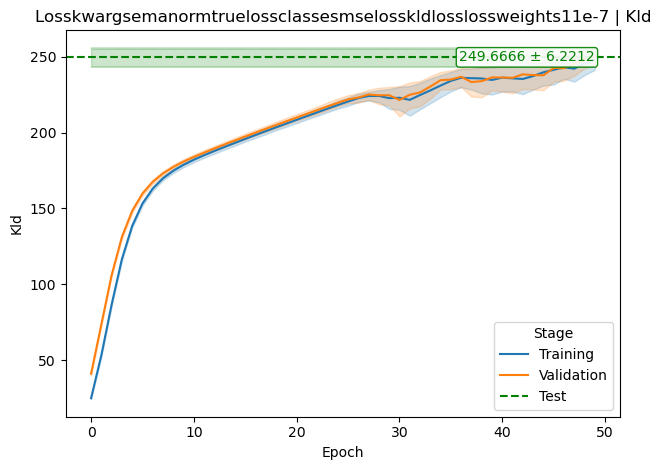

In [13]:
for key in figs.keys():
    display(figs[key]['kld'])

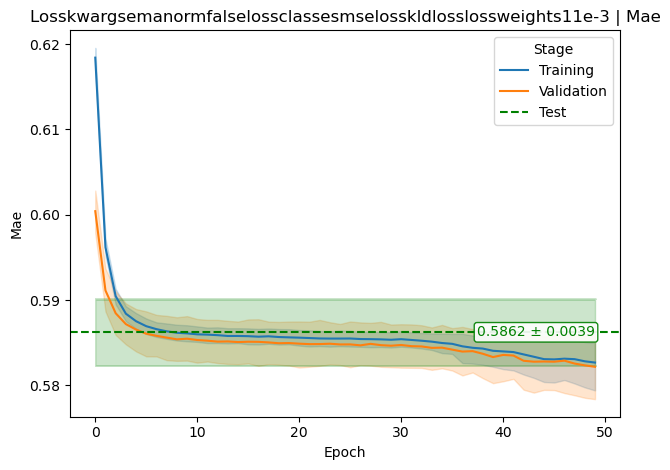

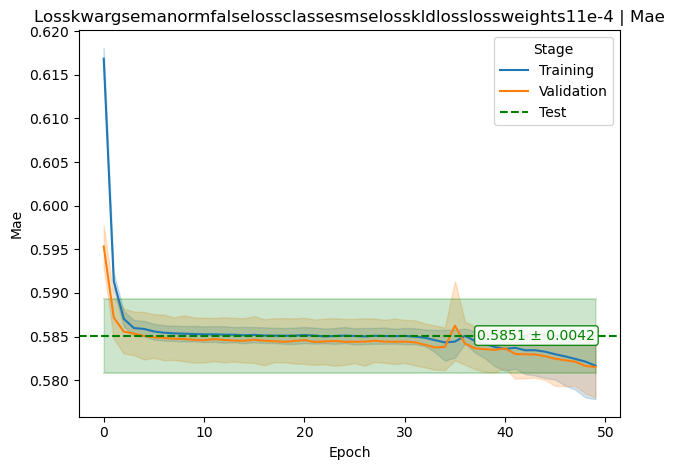

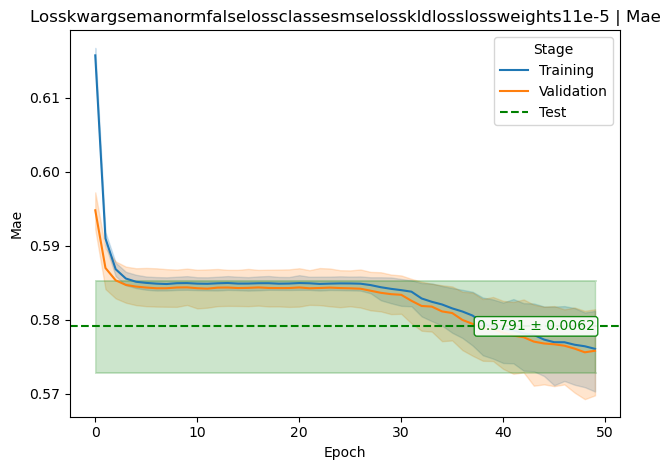

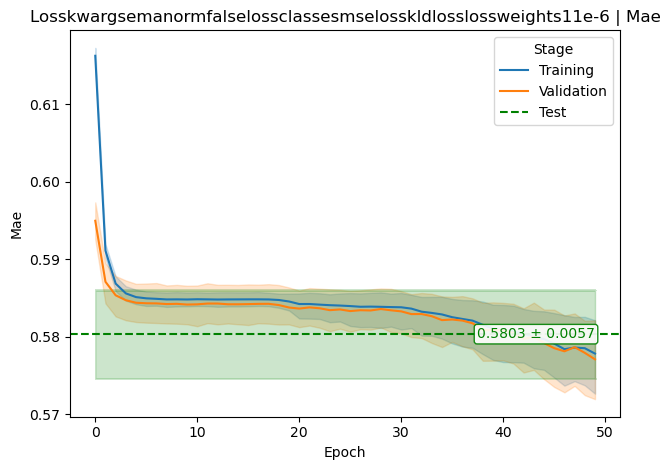

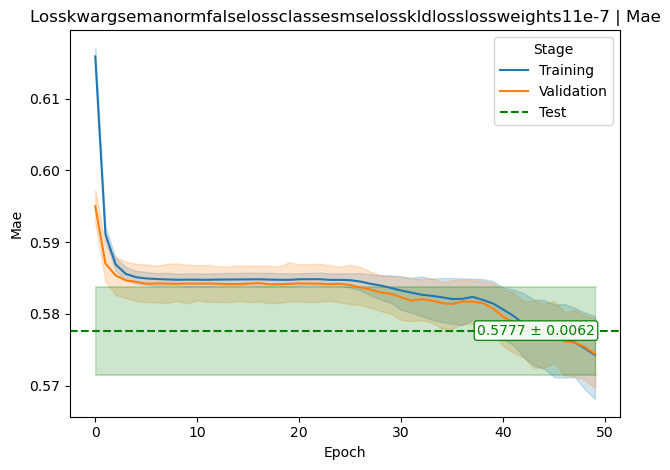

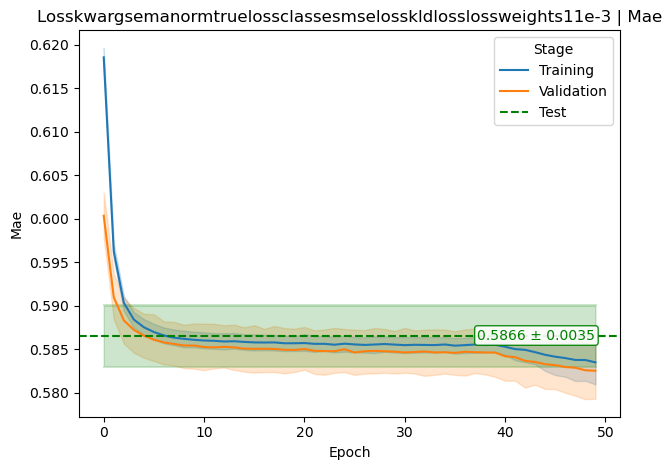

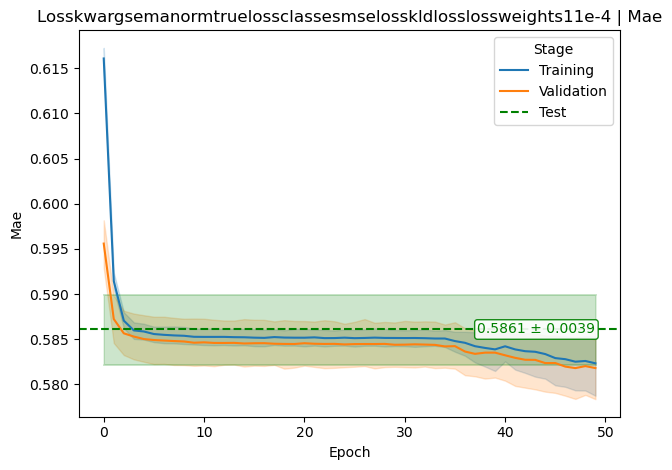

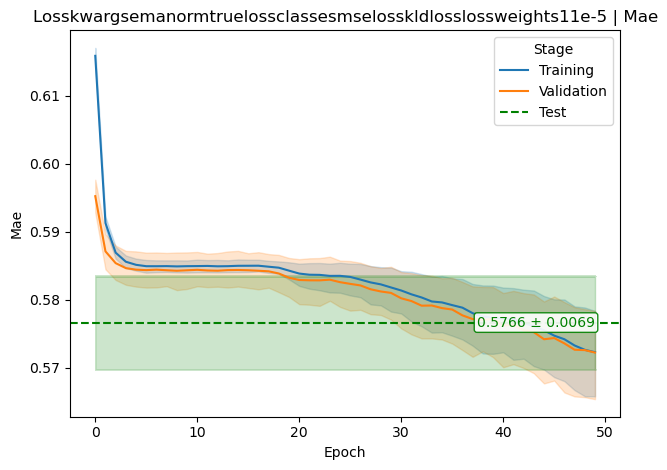

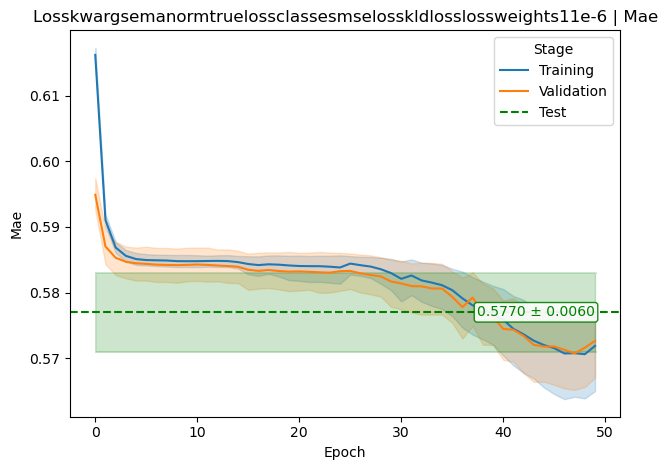

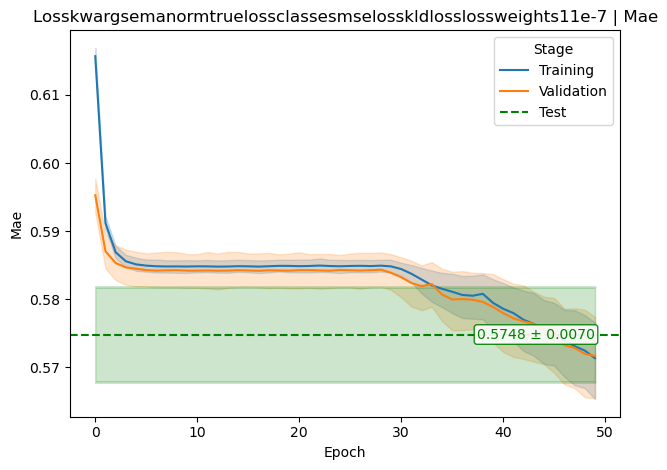

In [14]:
for key in figs.keys():
    display(figs[key]['mae'])